In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

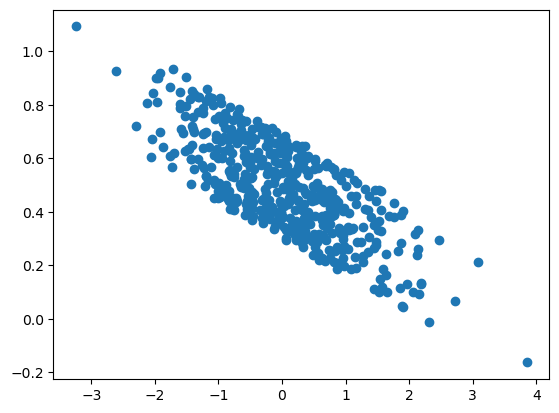

In [3]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1], y)
plt.show()

# Data A

In [4]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


## 1(a). Learning Rate

50. Training loss: 0.08822499761459246, Val loss:0.08344253861678516
100. Training loss: 0.024461533163063473, Val loss:0.022730598385935285
150. Training loss: 0.015054341888577384, Val loss:0.013961184271627123
200. Training loss: 0.013664791563666538, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002822
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964216, Val loss:0.012579546976647175
500. Training loss: 0.013423625043327498, Val loss:0.01257988125786218


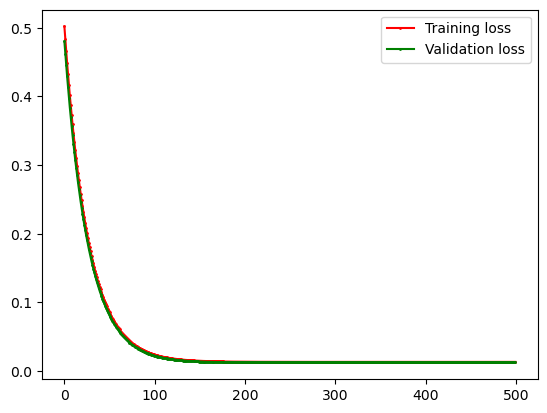

In [5]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


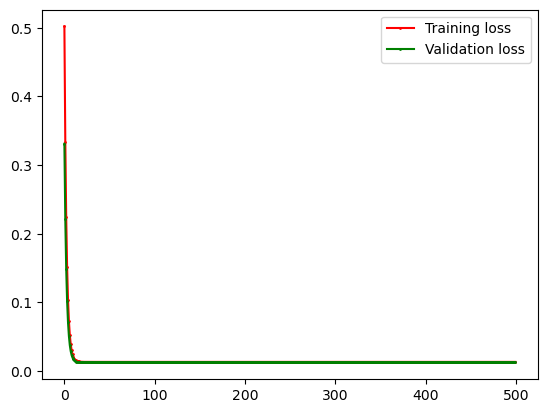

In [6]:
# lr = 0.1
np.random.seed(42)
model_01 = LinearModel(dim, True, loss_fn, grad_fn)
loss_01 = model_01.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

50. Training loss: 0.418984925274338, Val loss:0.41420880497204005
100. Training loss: 0.34884281364937003, Val loss:0.3445251797643867
150. Training loss: 0.2908358402579774, Val loss:0.28691334687110626
200. Training loss: 0.2428637953466062, Val loss:0.23928338706190336
250. Training loss: 0.20319008395293756, Val loss:0.19990713434668128
300. Training loss: 0.17037874765339453, Val loss:0.16735555250253287
350. Training loss: 0.14324239869173933, Val loss:0.1404469551481651
400. Training loss: 0.12079917484937551, Val loss:0.11820419110090803
450. Training loss: 0.10223715148116824, Val loss:0.09981924222927965
500. Training loss: 0.08688491828078371, Val loss:0.08462395006505144


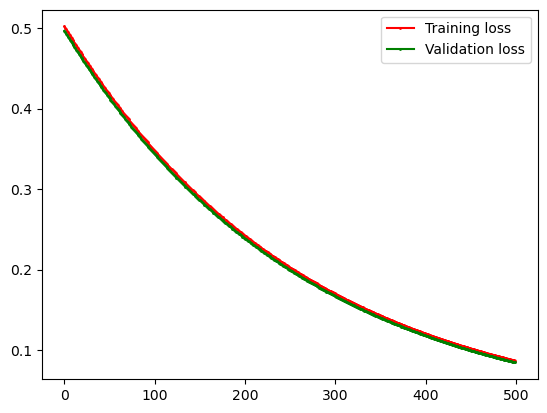

In [7]:
# lr = 0.001
np.random.seed(42)
model_0001 = LinearModel(dim, True, loss_fn, grad_fn)
loss_0001 = model_0001.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

In [8]:
# Get the Prediction
y_val_pred = model.predict(X_val)
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Data A - Linear Regression Evaluation (lr=0.01)'
)

=== Data A - Linear Regression Evaluation (lr=0.01) ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013355229539356039,
 'MAE': 0.10095149880498926,
 'RMSE': np.float64(0.11556482829717717),
 'R-squared': 0.5689997481843656}

In [9]:
y_val_pred_01 = model_01.predict(X_val)

evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_01,
    title='Data A - Linear Regression Evaluation (lr=0.1)'
)

=== Data A - Linear Regression Evaluation (lr=0.1) ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013356333749635324,
 'MAE': 0.10095600779556413,
 'RMSE': np.float64(0.11556960564800471),
 'R-squared': 0.5689641130867413}

In [10]:
y_val_pred_0001 = model_0001.predict(X_val)

evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_0001,
    title='Data A - Linear Regression Evaluation (lr=0.001)'
)

=== Data A - Linear Regression Evaluation (lr=0.001) ===
MSE       : 0.0832
MAE       : 0.2369
RMSE      : 0.2884
R-squared : -1.6836


{'MSE': 0.08315645283790848,
 'MAE': 0.23691757234746919,
 'RMSE': np.float64(0.28836860584659435),
 'R-squared': -1.6836268150701983}

# Data B

In [11]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_B.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


## Data B Learning Rate

50. Training loss: 0.21477796029761928, Val loss:0.20128111574984853
100. Training loss: 0.21477795969579408, Val loss:0.20128143543301202
150. Training loss: 0.2147779596957941, Val loss:0.20128143544080995
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


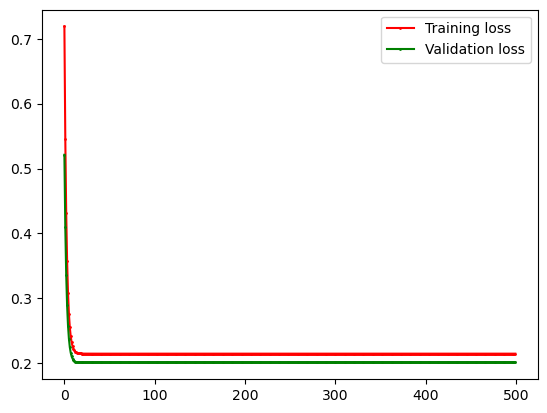

In [12]:
seed = 42
np.random.seed(seed)

# Loss & gradient
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset
X_train, y_train, X_val, y_val = get_train_val(X, y)

# lr = 0.1
np.random.seed(42)
model_B_01 = LinearModel(dim, True, loss_fn, grad_fn)
loss_B_01 = model_B_01.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

50. Training loss: 0.2920213425997664, Val loss:0.2702611408646165
100. Training loss: 0.22618379407532826, Val loss:0.2101879308116208
150. Training loss: 0.2164640141651331, Val loss:0.2021155812609517
200. Training loss: 0.21502743867502366, Val loss:0.20122361991141446
250. Training loss: 0.21481490508468085, Val loss:0.20120482979710497
300. Training loss: 0.21478343493349927, Val loss:0.20124452118342356
350. Training loss: 0.21477877162933798, Val loss:0.20126634873684507
400. Training loss: 0.21477808016505961, Val loss:0.20127557772119783
450. Training loss: 0.21477797757871428, Val loss:0.20127920153421996
500. Training loss: 0.2147779623514954, Val loss:0.20128058874123028


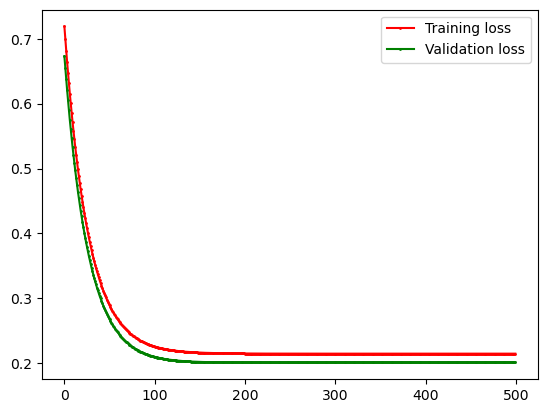

In [13]:
# lr = 0.01
np.random.seed(42)
model_B_001 = LinearModel(dim, True, loss_fn, grad_fn)
loss_B_001 = model_B_001.fit(X_train, y_train, lr=0.01, n_iteration=500, val_ratio=0.2)

50. Training loss: 0.6333011463329974, Val loss:0.605763731465133
100. Training loss: 0.560944176029853, Val loss:0.5347780170370382
150. Training loss: 0.5011005997675119, Val loss:0.47616215994096633
200. Training loss: 0.4516056474010014, Val loss:0.4277683253433776
250. Training loss: 0.41066917554133203, Val loss:0.3878209660417229
300. Training loss: 0.37681081233745717, Val loss:0.354852342304647
350. Training loss: 0.3488063343172151, Val loss:0.32764920718227697
400. Training loss: 0.32564332924740713, Val loss:0.3052087237083346
450. Training loss: 0.30648453628529515, Val loss:0.28670201534712025
500. Training loss: 0.2906375335120469, Val loss:0.27144402793270805


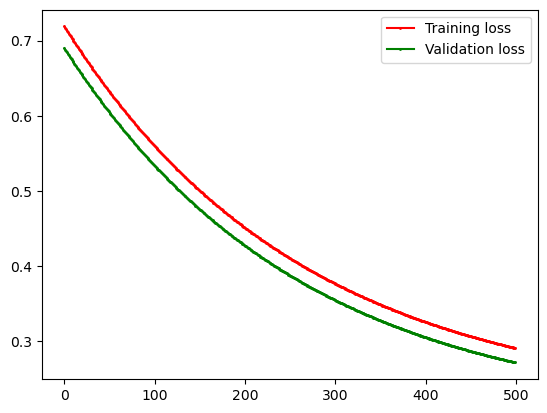

In [14]:
# lr = 0.001
np.random.seed(42)
model_B_0001 = LinearModel(dim, True, loss_fn, grad_fn)
loss_B_0001 = model_B_0001.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

In [15]:
# Prediction
y_val_pred_B_01 = model_B_01.predict(X_val)

# Evaluation
result_B_01 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_B_01,
    title='Data B - Linear Regression Evaluation (lr=0.1)'
)

=== Data B - Linear Regression Evaluation (lr=0.1) ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


In [16]:
# Prediction
y_val_pred_B_001 = model_B_001.predict(X_val)

# Evaluation
result_B_001 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_B_001,
    title='Data B - Linear Regression Evaluation (lr=0.01)'
)

=== Data B - Linear Regression Evaluation (lr=0.01) ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


In [17]:
# Prediction
y_val_pred_B_0001 = model_B_0001.predict(X_val)

# Evaluation
result_B_0001 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_B_0001,
    title='Data B - Linear Regression Evaluation (lr=0.001)'
)

=== Data B - Linear Regression Evaluation (lr=0.001) ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011


# Data C

In [18]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_C.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


## Data C Learning Rate

50. Training loss: 0.0131818971313023, Val loss:0.013771656751385359
100. Training loss: 0.013181896123422132, Val loss:0.013771595669720494
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175307


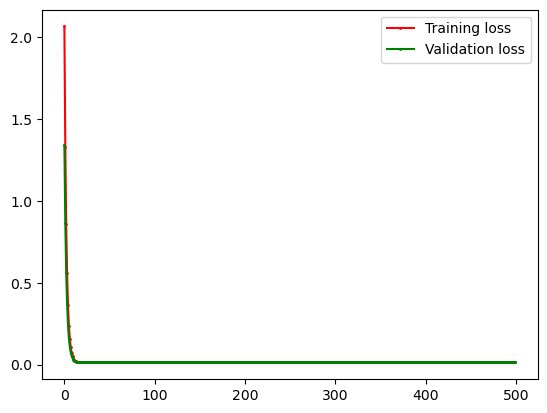

In [19]:
seed = 42
np.random.seed(seed)

loss_fn = MSE
grad_fn = MSE_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

# lr = 0.1
np.random.seed(42)
model_C_01 = LinearModel(dim, True, loss_fn, grad_fn)
loss_C_01 = model_C_01.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

50. Training loss: 0.3016776572102272, Val loss:0.2940364008397445
100. Training loss: 0.052301281914569585, Val loss:0.052286225702638675
150. Training loss: 0.018505850726527058, Val loss:0.019175412162323584
200. Training loss: 0.013908983721033275, Val loss:0.014564896297918123
250. Training loss: 0.013281521987973383, Val loss:0.013899712449279154
300. Training loss: 0.01319558969139006, Val loss:0.013796096535113092
350. Training loss: 0.013183783898695744, Val loss:0.013777427806772765
400. Training loss: 0.013182157103470477, Val loss:0.013773277022245267
450. Training loss: 0.013181932299897786, Val loss:0.013772140690770074
500. Training loss: 0.013181901150900593, Val loss:0.013771782558303799


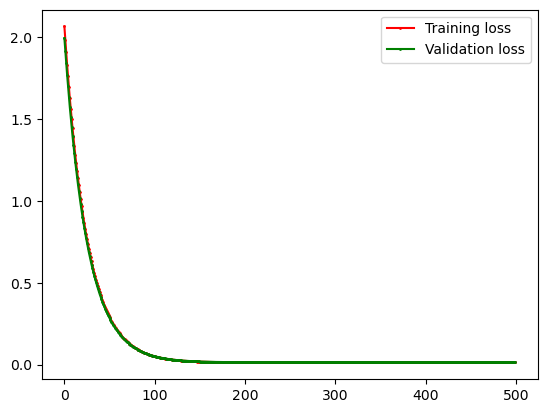

In [20]:
seed = 42
np.random.seed(seed)

loss_fn = MSE
grad_fn = MSE_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

# lr = 0.01
np.random.seed(42)
model_C_001 = LinearModel(dim, True, loss_fn, grad_fn)
loss_C_001 = model_C_001.fit(X_train, y_train, lr=0.01, n_iteration=500, val_ratio=0.2)

50. Training loss: 1.7022307356186879, Val loss:1.704399561902757
100. Training loss: 1.398099093422373, Val loss:1.4007211470145513
150. Training loss: 1.1487734111234604, Val loss:1.1516658664027397
200. Training loss: 0.9443693636081101, Val loss:0.9473976449419805
250. Training loss: 0.7767867515803092, Val loss:0.7798533335010577
300. Training loss: 0.6393871949572303, Val loss:0.642422853410673
350. Training loss: 0.5267301015086948, Val loss:0.5296870971374619
400. Training loss: 0.4343563650291918, Val loss:0.43720314708376423
450. Training loss: 0.3586111574044348, Val loss:0.3613282625111077
500. Training loss: 0.29649874274023047, Val loss:0.299075630842221


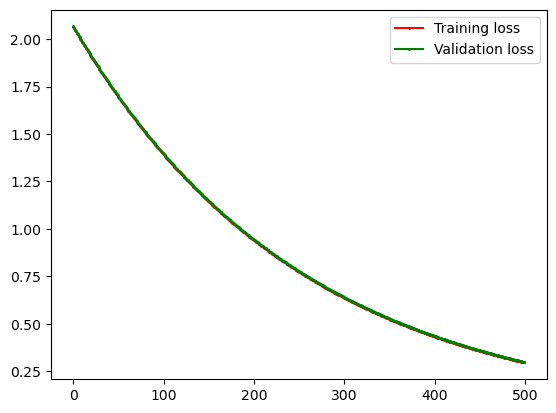

In [21]:
seed = 42
np.random.seed(seed)

loss_fn = MSE
grad_fn = MSE_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

# lr = 0.001
np.random.seed(42)
model_C_0001 = LinearModel(dim, True, loss_fn, grad_fn)
loss_C_0001 = model_C_0001.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

In [22]:
# Prediction
y_val_pred_C_01 = model_C_01.predict(X_val)

# Evaluation
result_C_01 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_C_01,
    title='Data C - Linear Regression Evaluation (lr=0.1)'
)

=== Data C - Linear Regression Evaluation (lr=0.1) ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


In [23]:
# Prediction
y_val_pred_C_001 = model_C_001.predict(X_val)

# Evaluation
result_C_001 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_C_001,
    title='Data C - Linear Regression Evaluation (lr=0.01)'
)

=== Data C - Linear Regression Evaluation (lr=0.01) ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


In [24]:
# Prediction
y_val_pred_C_0001 = model_C_0001.predict(X_val)

# Evaluation

result_C_0001 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_C_0001,
    title='Data C - Linear Regression Evaluation (lr=0.001)'
)

=== Data C - Linear Regression Evaluation (lr=0.001) ===
MSE       : 0.2852
MAE       : 0.4273
RMSE      : 0.5341
R-squared : 0.8994


# Data D

In [25]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


## Data D Learning Rate

50. Training loss: 0.08238685177710688, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
250. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
300. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
350. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
400. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
450. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
500. Training loss: 0.08238685077138833, Val loss:0.0860724729323457


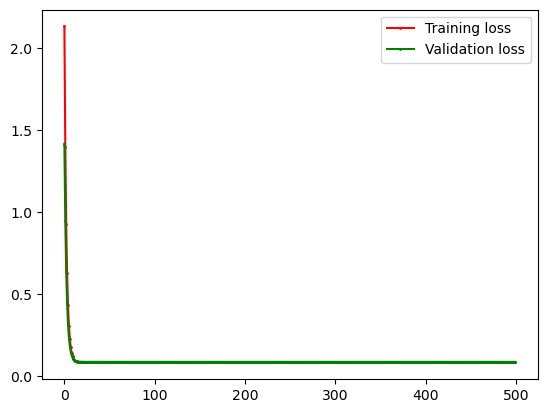

In [26]:
seed = 42
np.random.seed(seed)

# Loss & gradient
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset
X_train, y_train, X_val, y_val = get_train_val(X, y)

# lr = 0.1
np.random.seed(42)
model_D_01 = LinearModel(dim, True, loss_fn, grad_fn)
loss_D_01 = model_D_01.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

50. Training loss: 0.3703643487722047, Val loss:0.3686849563983318
100. Training loss: 0.1214345969859307, Val loss:0.1255385955779745
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594523, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529508
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.0823868868729943, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416795


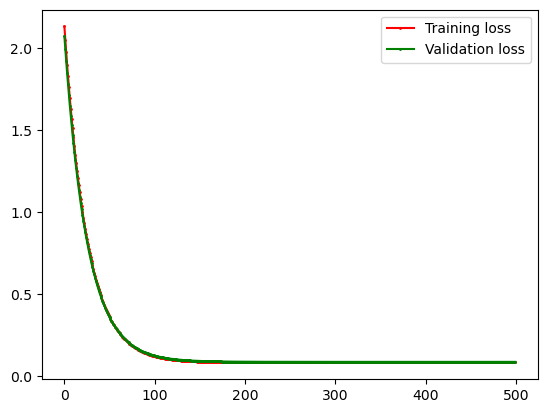

In [27]:
seed = 42
np.random.seed(seed)

# Loss & gradient
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset
X_train, y_train, X_val, y_val = get_train_val(X, y)


# lr = 0.01
np.random.seed(42)
model_D_001 = LinearModel(dim, True, loss_fn, grad_fn)
loss_D_001 = model_D_001.fit(X_train, y_train, lr=0.01, n_iteration=500, val_ratio=0.2)

50. Training loss: 1.7684511643778449, Val loss:1.7808955296769526
100. Training loss: 1.4648524964143852, Val loss:1.4770554865390984
150. Training loss: 1.2159645145907354, Val loss:1.2278106296911493
200. Training loss: 1.0119199428934709, Val loss:1.0233353741451867
250. Training loss: 0.8446325767970521, Val loss:0.8555746535033422
300. Training loss: 0.7074755244845349, Val loss:0.7179245466593898
350. Training loss: 0.5950176249327075, Val loss:0.6049705693586136
400. Training loss: 0.50280751484024, Val loss:0.5122732093945561
450. Training loss: 0.4271967232656893, Val loss:0.43619216922708653
500. Training loss: 0.3651947340371162, Val loss:0.3737423235472047


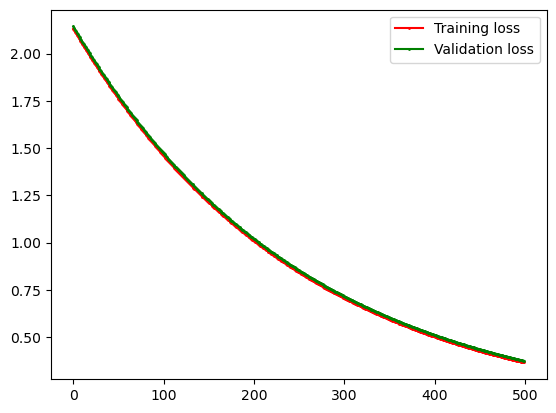

In [28]:
seed = 42
np.random.seed(seed)

# Loss & gradient
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset
X_train, y_train, X_val, y_val = get_train_val(X, y)

# lr = 0.001
np.random.seed(42)
model_D_0001 = LinearModel(dim, True, loss_fn, grad_fn)
loss_D_0001 = model_D_0001.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

In [29]:
# Prediction
y_val_pred_D_01 = model_D_01.predict(X_val)

# Evaluation
result_D_01 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_D_01,
    title='Data D - Linear Regression Evaluation (lr=0.1)'
)

=== Data D - Linear Regression Evaluation (lr=0.1) ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


In [30]:
# Prediction
y_val_pred_D_001 = model_D_001.predict(X_val)


# Evaluation
result_D_001 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_D_001,
    title='Data D - Linear Regression Evaluation (lr=0.01)'
)

=== Data D - Linear Regression Evaluation (lr=0.01) ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


In [31]:
# Prediction
y_val_pred_D_0001 = model_D_0001.predict(X_val)

# Evaluation
result_D_0001 = evaluate_linear_regression(
    y_true=y_val,
    y_pred=y_val_pred_D_0001,
    title='Data D - Linear Regression Evaluation (lr=0.001)'
)

=== Data D - Linear Regression Evaluation (lr=0.001) ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780
